<font size =8> Barnacle Detection after multi-step Post-processing</font>


<font size =4>
This experiment investigates progressive fine-tuning a pre-trained YOLOv8 segmentation model across three sequential stages to enhance barnacle detection.

The model will be fine-tuned:

1. On a large dataset of of satellite images of buildings. 
2. Then, on a smaller dataset of polygons that resemble the shape of barnacles
3. Finally, on our custom barnacle dataset for specific task specialization.

This multi-stage approach explores how successive domain adaptation impacts model performance. My hypothesis is that progressive fine-tuning on relevant intermediate datasets will significantly lower the initial loss when training on subsequent stages, indicating improved feature initialization and overall performance.

In [1]:
import matplotlib.pyplot as plt
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import fiftyone as fo 
from PIL import Image
import numpy as np

<font size =6><u>Training Stage 1</u></font>


<font size =4> Firstly, I train the model on bash a dataset of aerial images of building layouts. I do this with the intention of improving the model's campabilities in pixel-wise segmentation. The script for the training process can be found on the Progressivefinetuning.ipynb. The dataset was downloaded from [roboflow](https://universe.roboflow.com/building-1yuss/building-hqjen/dataset/1/download).  

To download the dataset, you will need to have a roboflow account. Once you make an account, follow the steps below: 
1. Open the aforementioned link
2. Press on Download->Download dataset
3. Select the 'Image and Annotation Format' as YOLOv8(or others if you wanna try a different model)
4. Press on the download option you prefer.

<font size =6><u>Training Details</u></font>

<font size =4>Training data = 7739<br>
Val data = 1936<br>
batch size = 16<br>
epochs =20

Below are graphs for the visualization of the training. As you can see, the loss decreases but does not converge. Larger epoch size might lead to convergence but at the same time, might lead to overfitting as well. If you want to see more details about this training step, check out `training_stage_1` sub-directory 

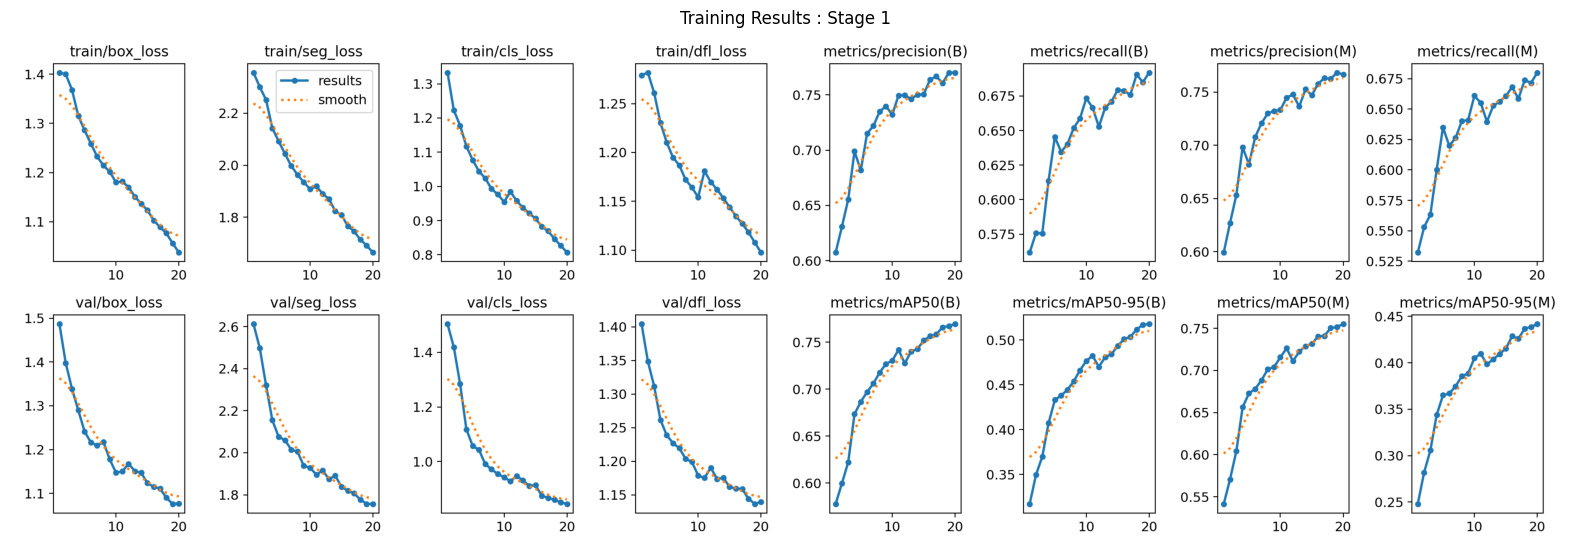

In [2]:
img = np.asarray(Image.open("training_stage_1/results.png"))
plt.figure(figsize=(20,20))
plt.title("Training Results : Stage 1")
plt.axis("off")
plt.imshow(img)
plt.show()


<font size = 6>Training Stage 2</font>

<foint size =4> For this stage, I train the recently trained model on an oilpalm dataset. While this sounds extremely out of context, the annotations show very close resemblance to barnacles. I believe training the model on this image segmentation dataset might lead to improved performances. Like the building outline dataset, this dataset can also be found on [roboflow](https://universe.roboflow.com/testi-vq2kh/polygon-campur/dataset/10#). To download, follow the same steps as above.

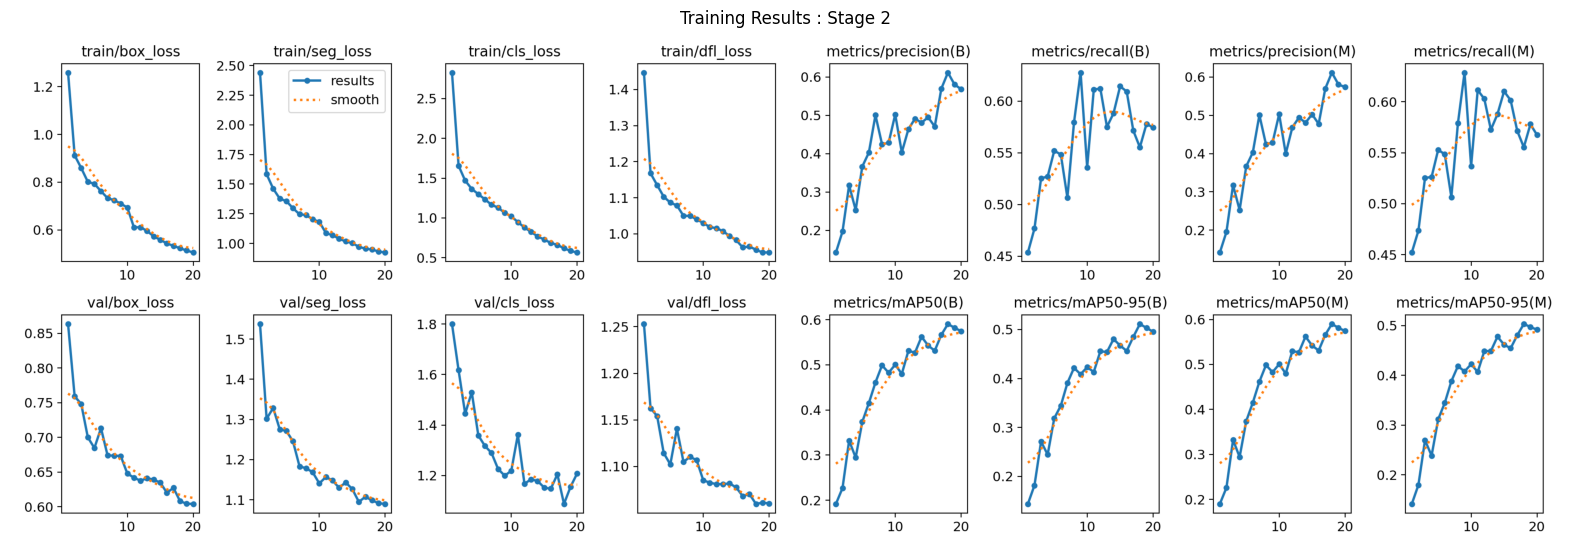

In [3]:
img = np.asarray(Image.open("training_stage_2/results.png"))
plt.figure(figsize=(20,20))
plt.title("Training Results : Stage 2")
plt.axis("off")
plt.imshow(img)
plt.show()


<font size = 4.5> The model converges decreases with epochs completed. Following this training, I will perform a final tuning on the custom dataset that I prepared and examine the changes in performance due to the progressive fine-tuning. While I believe this won't lead to drastic changes as the other model did pretty well just on the custom dataset, any improvement would indicate this approach of training on unrelated datasets can be taken when there is limited data. 

More training information and stats are present in the `training_stage_2` subdirectory. 

<font size = 6> Stage 3: Final Training</font>

<font size =4> In this stage, I finally train it on the dataset I prepared using the two images provided to us. While YOLOv8 is generally a good model for image detection(bounding boxes), it slightly lacks in the field of image segmentation(pixel-wise mapping). By training it on multiple datasets for segmentation task, I hoped to improve this performance in order to achieve an even more robust performance. The training was done a Google collab notebook present(present in this directory). Below, I have attached the results of the cross validation training process

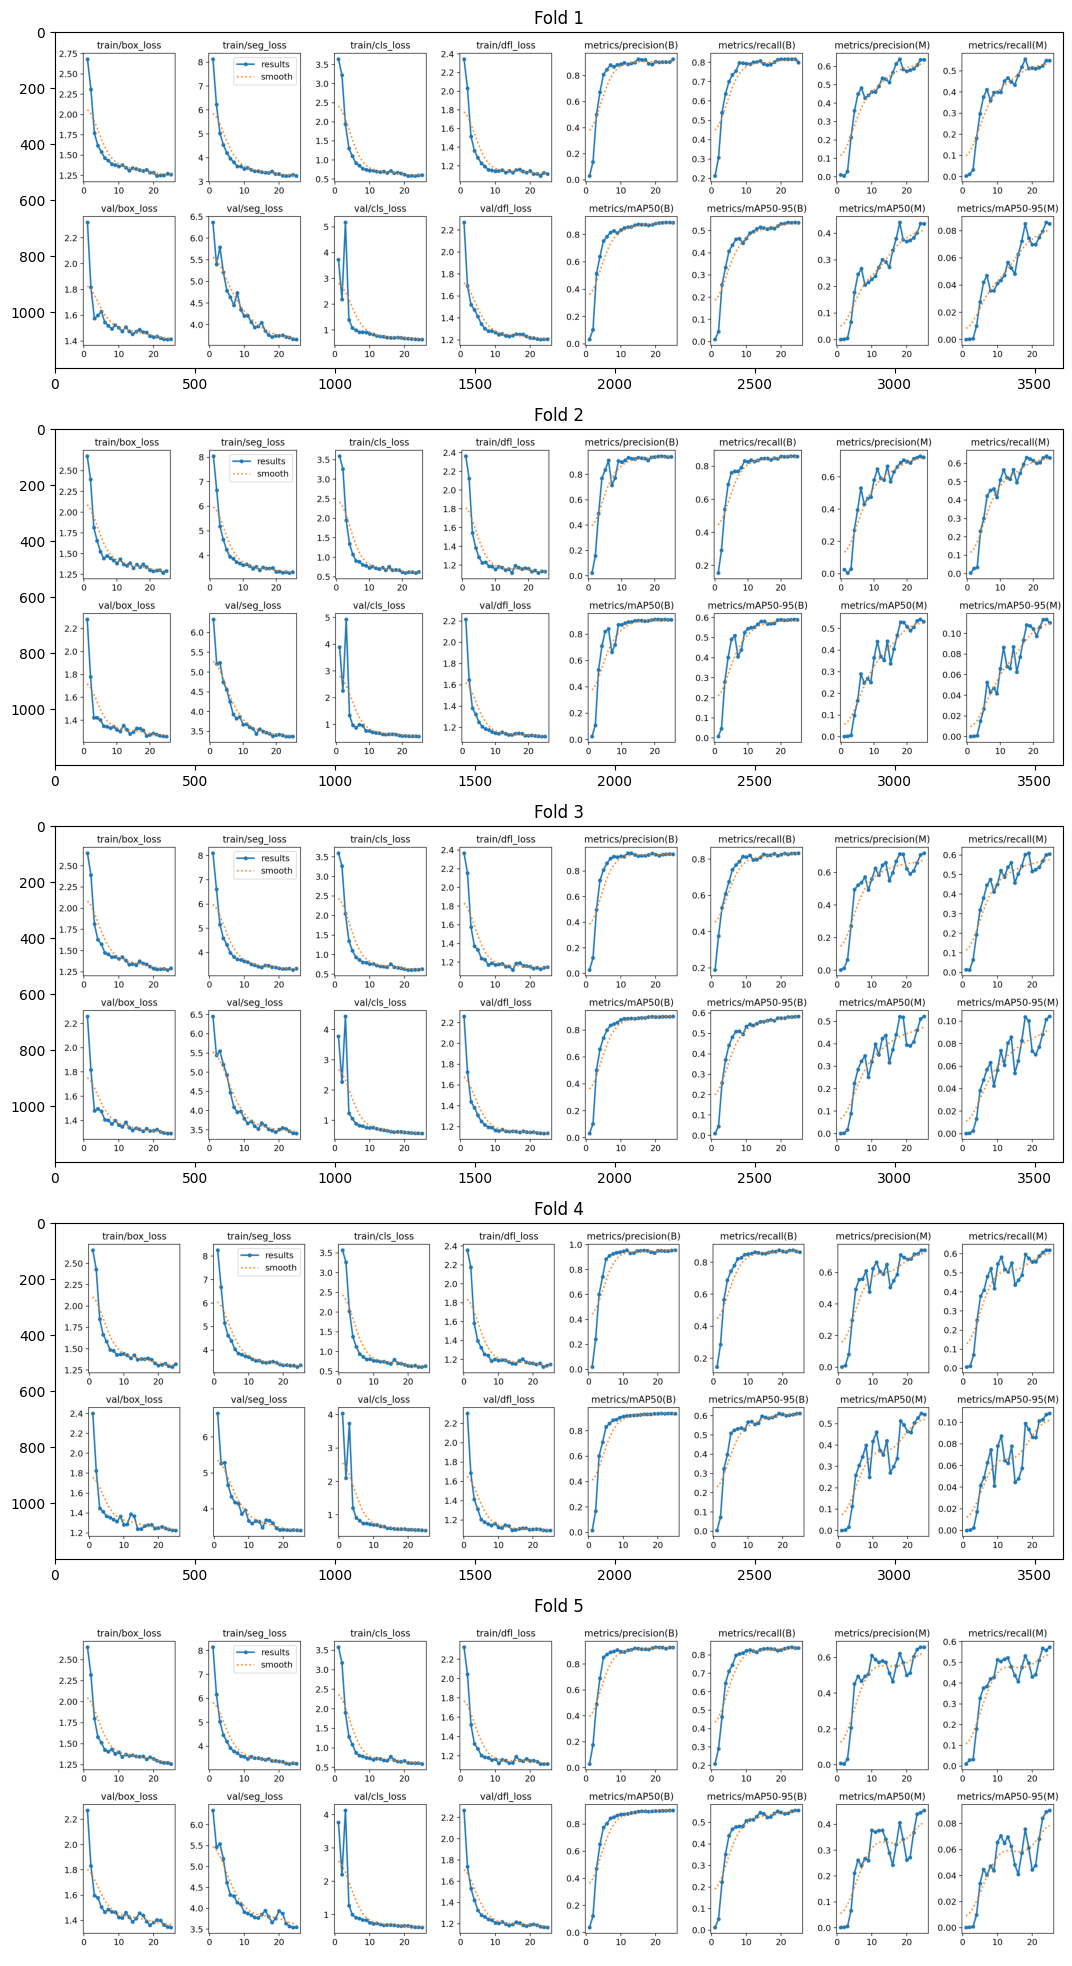

In [5]:
img1 = np.asarray(Image.open("KFold_training_barnacles_PFT/fold_1/results.png"))
img2 = np.asarray(Image.open("KFold_training_barnacles_PFT/fold_2/results.png"))
img3 = np.asarray(Image.open("KFold_training_barnacles_PFT/fold_3/results.png"))
img4 = np.asarray(Image.open("KFold_training_barnacles_PFT/fold_4/results.png"))
img5 = np.asarray(Image.open("KFold_training_barnacles_PFT/fold_5/results.png"))

fig, axes = plt.subplots(5,1, figsize=(20,20))

#fold1
axes[0].imshow(img1) 
axes[0].set_title('Fold 1')

#fold2
axes[1].imshow(img2) 
axes[1 ].set_title('Fold 2')

#fold3
axes[2].imshow(img3) 
axes[2].set_title('Fold 3')

#fold4
axes[3].imshow(img4)
axes[3].set_title('Fold 4')

#fold5
axes[4].imshow(img5) 
axes[4].set_title('Fold 5')


plt.tight_layout()
plt.axis('off')
plt.show()

<font size =4.5> In general, the training loss seems to decrease by more than half on all folds for both training and validation. There is a consistent pattern of sharp increase in val/cls_loss across all folds in the first few epochs, but it quickly converges after that. These graphs indicate that the training was pretty effective and successful

You can find more detailed information regarding the rraining of each fold within the `Kfold_training_barnacles` subdirectory. 

<font size = 6> Initializing and Inference</font>


<font size =4.5>Similar to the other model, I predict the number of barnacles by performing a rudimentary ensembling of the models from the 5-fold cross validation. However, it works different han the other model as it performs a segmentation task as opposed to detection. The main different is the way the objects are annotated. In detection, objects are identified using boudning boxes, whereas in segmentation, the annotations are more pixe-wise masking of the objects.

In [6]:

def sahi_inference(image_filepath, model): 
    
    result = get_sliced_prediction(
        image_filepath,
        model, slice_height=256,
        slice_width=256,
        postprocess_match_metric="IOU",
        postprocess_match_threshold=0.4,
        overlap_height_ratio=0.2,
        postprocess_class_agnostic = True,
        overlap_width_ratio=0.2,
        )
    return result


<font size =6><u> Image 1</u>

In [8]:
numbers_1 =[]

for i in range(5): 
    model=  AutoDetectionModel.from_pretrained(
        model_type = "yolov8", 
        model_path = f'KFold_training_barnacles_PFT/fold_{i+1}/best.pt', 
        confidence_threshold=0.5, 
        device ="cpu")
    result = sahi_inference("../unseen_images/unseen_img1.png", model)
    object_predictionlist = result.object_prediction_list
    number = len(object_predictionlist)
    numbers_1.append(number)
    
mean_value = int(sum(numbers_1) / len(numbers_1))
print(f"The number of barnacles in first unseen image is {mean_value} ")

Performing prediction on 64 slices.
Performing prediction on 64 slices.
Performing prediction on 64 slices.
Performing prediction on 64 slices.
Performing prediction on 64 slices.
The number of barnacles in first unseen image is 1297 


<font size =6><u> Image 2</u>

In [13]:
numbers_2 =[]

for i in range(5): 
    model=  AutoDetectionModel.from_pretrained(
        model_type = "yolov8", 
        model_path = f'KFold_training_barnacles_PFT/fold_{i+1}/best.pt', 
        confidence_threshold=0.5, 
        device ="cpu")
    result = sahi_inference("../unseen_images/unseen_img2.png", model)
    object_predictionlist = result.object_prediction_list
    number = len(object_predictionlist)
    numbers_2.append(number)
    
mean_value = int(sum(numbers_2) / len(numbers_2))
print(f"The number of barnacles in first unseen image is {mean_value} ")

Performing prediction on 9 slices.
Performing prediction on 9 slices.
Performing prediction on 9 slices.
Performing prediction on 9 slices.
Performing prediction on 9 slices.
The number of barnacles in first unseen image is 160 
